In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

### Dataset Loading

In [2]:
df = pd.read_csv("C:/Users/Admin/Downloads/walmart/Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
print("Dataset Summary:")
print(df.info())

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
None


### Missing-Value

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


### Date Parsing

In [5]:
# Convert Date column safely
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

# Check if any date failed to parse
invalid_dates = df['Date'].isna().sum()
print("Invalid date entries:", invalid_dates)

# Remove invalid dates (if any)
df = df.dropna(subset=['Date'])

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

Invalid date entries: 0


### Duplicate Checks

In [6]:
duplicates = df.duplicated().sum()
print("Duplicate rows found:", duplicates)

# Drop duplicates if they exist
df = df.drop_duplicates().reset_index(drop=True)

Duplicate rows found: 0


In [7]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00.000000256,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


### Distribution Checks

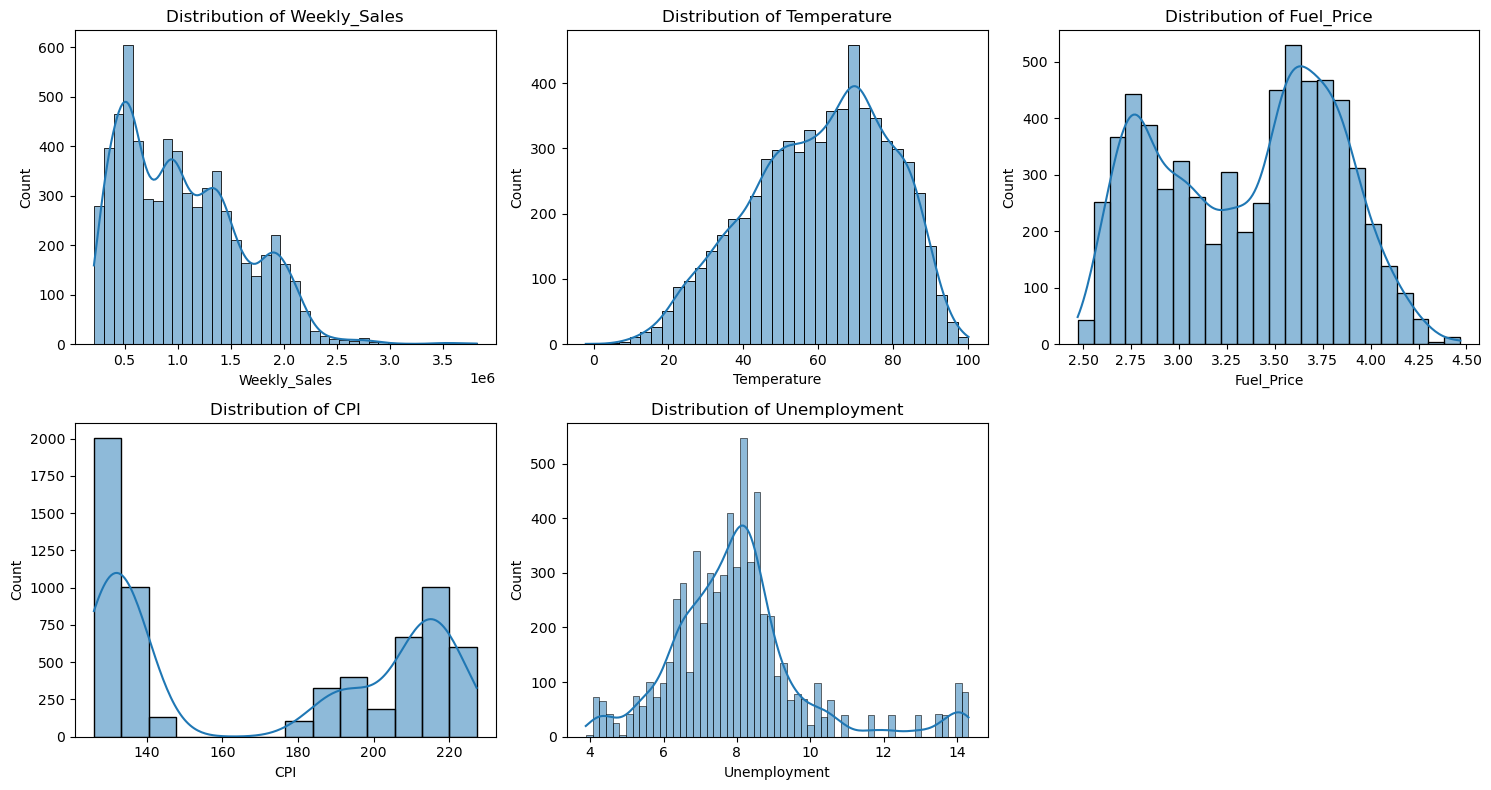

In [8]:
num_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

plt.figure(figsize=(15,8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


### Feature Scaling (for exogenous variables)

In [9]:
#Random Forest doesn’t strictly need scaling, but SARIMAX + RF together work more stably if exogenous variables are scaled.

scale_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,0.434149,0.050100,0.840500,0.405118
1,10,2010-02-05,2193048.75,0,0.551859,0.245491,0.003737,0.564117
2,37,2010-02-05,536006.73,0,0.469961,0.050100,0.828209,0.448054
3,17,2010-02-05,789036.02,0,0.246282,0.097194,0.003737,0.255798
4,30,2010-02-05,465108.52,0,0.402250,0.050100,0.837102,0.426011


### Aggregate Weekly Sales Across All Stores

In [10]:
weekly = df.groupby('Date').agg({
    'Weekly_Sales': 'sum',
    'Holiday_Flag': 'max',      
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean'
}).reset_index()

print("Weekly shape:", weekly.shape)
weekly.head()

Weekly shape: (143, 7)


,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,0,0.353203,0.123169,0.411855,0.454314
1,2010-02-12,48336677.63,1,0.354318,0.111234,0.412791,0.454314
2,2010-02-19,48276993.78,0,0.389235,0.100234,0.413247,0.454314
3,2010-02-26,43968571.13,0,0.404144,0.106179,0.413622,0.454314
4,2010-03-05,46871470.30,0,0.440091,0.129860,0.413997,0.454314


### Time Features & Lag/Rolling Features

In [11]:
# Calendar features
weekly['Year'] = weekly['Date'].dt.year
weekly['Month'] = weekly['Date'].dt.month
weekly['WeekOfYear'] = weekly['Date'].dt.isocalendar().week.astype(int)
weekly['Quarter'] = weekly['Date'].dt.quarter
weekly['DayOfWeek'] = weekly['Date'].dt.dayofweek  # mostly 0, but keep for completeness

# Lag features: previous weeks
for lag in [1, 2, 4, 8, 12]:
    weekly[f'lag_{lag}'] = weekly['Weekly_Sales'].shift(lag)

# Rolling mean features
for w in [4, 8, 12]:
    weekly[f'roll_mean_{w}'] = weekly['Weekly_Sales'].shift(1).rolling(window=w).mean()

# Exponential weighted moving average
weekly['ewm_4'] = weekly['Weekly_Sales'].shift(1).ewm(span=4).mean()
weekly['ewm_8'] = weekly['Weekly_Sales'].shift(1).ewm(span=8).mean()

# Drop rows with NaNs (from lags/rolling)
weekly = weekly.dropna().reset_index(drop=True)

weekly.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,WeekOfYear,...,lag_1,lag_2,lag_4,lag_8,lag_12,roll_mean_4,roll_mean_8,roll_mean_12,ewm_4,ewm_8
0,2010-04-30,43705126.71,0,0.586249,0.210187,0.410497,0.44266,2010,4,17,...,44734452.56,45183667.08,50423831.26,46871470.30,49750740.50,4.692681e+07,4.620338e+07,4.666334e+07,4.576297e+07,4.613098e+07
1,2010-05-07,48503243.52,0,0.647604,0.230394,0.410153,0.44266,2010,5,18,...,43705126.71,44734452.56,47365290.44,45925396.51,48336677.63,4.524713e+07,4.580759e+07,4.615953e+07,4.493876e+07,4.557054e+07
2,2010-05-14,45330080.20,0,0.613205,0.237976,0.410032,0.44266,2010,5,19,...,48503243.52,43705126.71,45183667.08,44988974.64,48276993.78,4.553162e+07,4.612982e+07,4.617341e+07,4.636567e+07,4.624216e+07
3,2010-05-21,45120108.06,0,0.668519,0.226509,0.411248,0.44266,2010,5,20,...,45330080.20,48503243.52,44734452.56,44133961.05,43968571.13,4.556823e+07,4.617246e+07,4.592784e+07,4.595124e+07,4.603470e+07
4,2010-05-28,47757502.56,0,0.709591,0.197606,0.412463,0.44266,2010,5,21,...,45120108.06,45330080.20,43705126.71,50423831.26,46871470.30,4.566464e+07,4.629572e+07,4.602380e+07,4.561869e+07,4.582774e+07


### Train/Test Split (Time-Based)

In [12]:
weekly = weekly.sort_values('Date').reset_index(drop=True)

n = len(weekly)
split_idx = int(n * 0.8)

train = weekly.iloc[:split_idx].copy()
test  = weekly.iloc[split_idx:].copy()

print("Train size:", train.shape)
print("Test size :", test.shape)

Train size: (104, 22)
Test size : (27, 22)


### Define Features for Random Forest

In [13]:
feature_cols = [
    'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'Year', 'Month', 'WeekOfYear', 'Quarter',
    'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12',
    'roll_mean_4', 'roll_mean_8', 'roll_mean_12',
    'ewm_4', 'ewm_8'
]

X_train_rf = train[feature_cols]
y_train_rf = train['Weekly_Sales']

X_test_rf  = test[feature_cols]
y_test = test['Weekly_Sales']

X_train_rf.shape, X_test_rf.shape

((104, 19), (27, 19))

### SARIMAX (ARIMA with Exogenous Variables) Baseline Model

In [14]:
# Set Date as index
train_ts = train.set_index('Date')
test_ts  = test.set_index('Date')

exog_train = train_ts[['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]
exog_test  = test_ts[['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]

# SARIMAX: (p,d,q) + (P,D,Q,s) – here s=52 weeks approx for yearly seasonality
sarimax_model = SARIMAX(
    endog=train_ts['Weekly_Sales'],
    exog=exog_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)
print(sarimax_result.summary())

C:\Users\Admin\miniconda3\envs\adm\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\miniconda3\envs\adm\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\miniconda3\envs\adm\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\Admin\miniconda3\envs\adm\lib\site-packages\statsmodels\tools\eval_measures.py:414: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
C:\Users\Admin\miniconda3\envs\adm\lib\site-packages\statsmodels\too

                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  104
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                   0.000
Date:                            Wed, 26 Nov 2025   AIC                             20.000
Time:                                    23:41:38   BIC                                nan
Sample:                                04-30-2010   HQIC                               nan
                                     - 04-20-2012                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Holiday_Flag          0         -0        nan        nan           0           0
Temperature  -2.452e+06      

C:\Users\Admin\miniconda3\envs\adm\lib\site-packages\statsmodels\tsa\stattools.py:472: RuntimeWarning: Mean of empty slice.
  xo = x - x.mean()
C:\Users\Admin\miniconda3\envs\adm\lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### SARIMAX Forecast on Test Period

In [15]:
sarimax_forecast = sarimax_result.predict(
    start=test_ts.index[0],
    end=test_ts.index[-1],
    exog=exog_test
)

# Align series
sarimax_forecast = sarimax_forecast.reindex(test_ts.index)

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

sarimax_mae = mean_absolute_error(y_test, sarimax_forecast)
sarimax_rmse = np.sqrt(mean_squared_error(y_test, sarimax_forecast))
sarimax_mape = mape(y_test, sarimax_forecast)

print("SARIMAX Baseline:")
print("MAE :", sarimax_mae)
print("RMSE:", sarimax_rmse)
print("MAPE:", sarimax_mape, "%")

SARIMAX Baseline:
MAE : 76850857.71927111
RMSE: 77092885.2238188
MAPE: 164.50247450140967 %


### Train Random Forest on Residuals (Hybrid Part)

In [16]:
# RF learn what SARIMAX misses.

# Get in-sample fitted values on training period
train['sarimax_fitted'] = sarimax_result.fittedvalues.values

# Residual = actual - SARIMAX fitted
train['residual'] = train['Weekly_Sales'] - train['sarimax_fitted']

X_train_hybrid = train[feature_cols]
y_train_hybrid = train['residual']

X_test_hybrid = test[feature_cols]

X_train_hybrid.head()

,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,WeekOfYear,Quarter,lag_1,lag_2,lag_4,lag_8,lag_12,roll_mean_4,roll_mean_8,roll_mean_12,ewm_4,ewm_8
0,0,0.586249,0.210187,0.410497,0.44266,2010,4,17,2,44734452.56,45183667.08,50423831.26,46871470.30,49750740.50,4.692681e+07,4.620338e+07,4.666334e+07,4.576297e+07,4.613098e+07
1,0,0.647604,0.230394,0.410153,0.44266,2010,5,18,2,43705126.71,44734452.56,47365290.44,45925396.51,48336677.63,4.524713e+07,4.580759e+07,4.615953e+07,4.493876e+07,4.557054e+07
2,0,0.613205,0.237976,0.410032,0.44266,2010,5,19,2,48503243.52,43705126.71,45183667.08,44988974.64,48276993.78,4.553162e+07,4.612982e+07,4.617341e+07,4.636567e+07,4.624216e+07
3,0,0.668519,0.226509,0.411248,0.44266,2010,5,20,2,45330080.20,48503243.52,44734452.56,44133961.05,43968571.13,4.556823e+07,4.617246e+07,4.592784e+07,4.595124e+07,4.603470e+07
4,0,0.709591,0.197606,0.412463,0.44266,2010,5,21,2,45120108.06,45330080.20,43705126.71,50423831.26,46871470.30,4.566464e+07,4.629572e+07,4.602380e+07,4.561869e+07,4.582774e+07


### Train Random Forest Regressor 

In [17]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_hybrid, y_train_hybrid)

# RF prediction of residuals on test period
rf_resid_pred = rf.predict(X_test_hybrid)

### Build Hybrid Forecast & Evaluate

In [18]:
# Hybrid forecast = SARIMAX forecast + RF residual correction
hybrid_forecast = sarimax_forecast + rf_resid_pred

hybrid_mae = mean_absolute_error(y_test, hybrid_forecast)
hybrid_rmse = np.sqrt(mean_squared_error(y_test, hybrid_forecast))
hybrid_mape = mape(y_test, hybrid_forecast)

print("SARIMAX (ARIMA) baseline:")
print(" MAE :", sarimax_mae)
print(" RMSE:", sarimax_rmse)
print(" MAPE:", sarimax_mape, "%")
print("-"*40)
print("Hybrid SARIMAX + RF:")
print(" MAE :", hybrid_mae)
print(" RMSE:", hybrid_rmse)
print(" MAPE:", hybrid_mape, "%")

SARIMAX (ARIMA) baseline:
 MAE : 76850857.71927111
 RMSE: 77092885.2238188
 MAPE: 164.50247450140967 %
----------------------------------------
Hybrid SARIMAX + RF:
 MAE : 29342315.555386145
 RMSE: 29923655.392603744
 MAPE: 62.76331905985582 %


### Plot Actual vs SARIMAX vs Hybrid

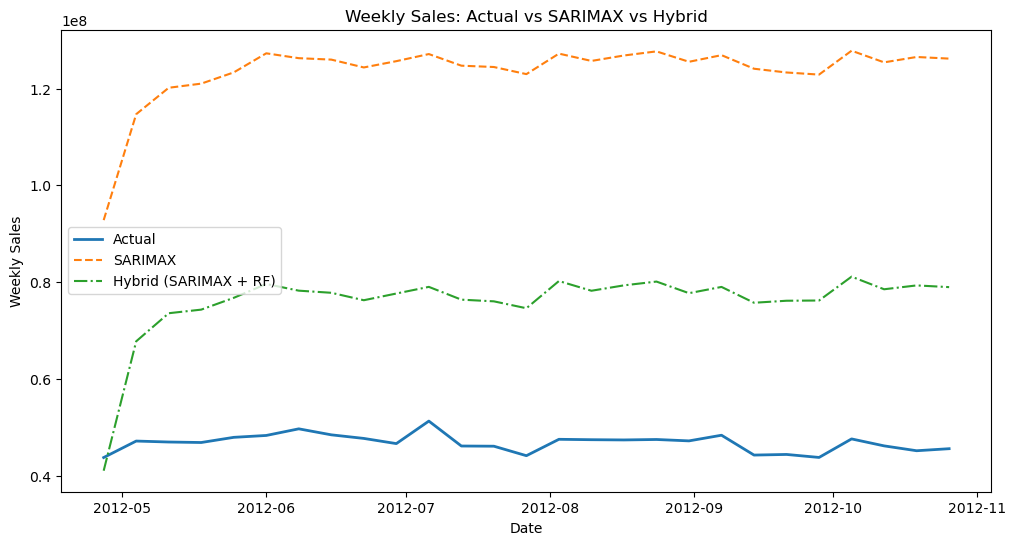

In [19]:
plt.figure(figsize=(12,6))
plt.plot(test_ts.index, y_test.values, label="Actual", linewidth=2)
plt.plot(test_ts.index, sarimax_forecast.values, label="SARIMAX", linestyle='--')
plt.plot(test_ts.index, hybrid_forecast, label="Hybrid (SARIMAX + RF)", linestyle='-.')
plt.legend()
plt.title("Weekly Sales: Actual vs SARIMAX vs Hybrid")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

### Feature Importance (Explainability for SMEs)

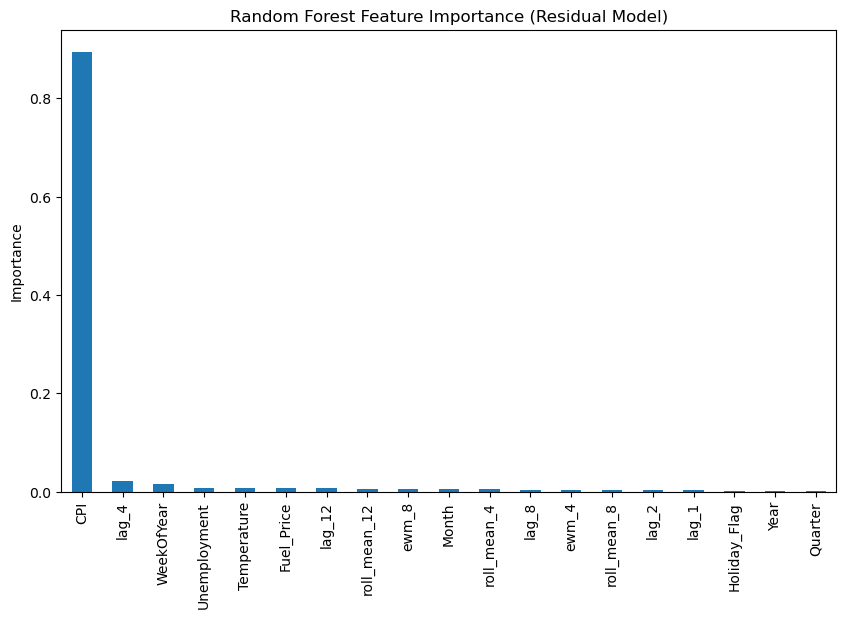

CPI             0.894876
lag_4           0.021947
WeekOfYear      0.014507
Unemployment    0.007888
Temperature     0.007314
Fuel_Price      0.006638
lag_12          0.006494
roll_mean_12    0.006000
ewm_8           0.005763
Month           0.005394
roll_mean_4     0.004624
lag_8           0.004118
ewm_4           0.004060
roll_mean_8     0.003957
lag_2           0.002726
lag_1           0.002370
Holiday_Flag    0.000558
Year            0.000407
Quarter         0.000360
dtype: float64

In [20]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title("Random Forest Feature Importance (Residual Model)")
plt.ylabel("Importance")
plt.show()

importances

### Simple Inventory Insight (Safety Stock Approximation)

In [21]:
# Align predictions and test data
valid_idx = hybrid_forecast.dropna().index

y_test_aligned = y_test.loc[valid_idx]
hybrid_aligned = hybrid_forecast.loc[valid_idx]

# Compute forecast errors
errors = y_test_aligned - hybrid_aligned
error_std = errors.std()

# Safety Stock calculation
z = 1.65  # for 95% service level
lead_time_weeks = 2

safety_stock = z * error_std * np.sqrt(lead_time_weeks)

print("Standard Deviation of Errors:", error_std)
print("Estimated Safety Stock:", safety_stock)


KeyError: "None of [DatetimeIndex(['2012-04-27', '2012-05-04', '2012-05-11', '2012-05-18',\n               '2012-05-25', '2012-06-01', '2012-06-08', '2012-06-15',\n               '2012-06-22', '2012-06-29', '2012-07-06', '2012-07-13',\n               '2012-07-20', '2012-07-27', '2012-08-03', '2012-08-10',\n               '2012-08-17', '2012-08-24', '2012-08-31', '2012-09-07',\n               '2012-09-14', '2012-09-21', '2012-09-28', '2012-10-05',\n               '2012-10-12', '2012-10-19', '2012-10-26'],\n              dtype='datetime64[ns]', name='Date', freq=None)] are in the [index]"

In [ ]:
print(train.shape)
print(test.shape)
print(errors.shape)
print(errors.std())